In [1]:
import numpy as np 
import pandas as pd 

In [2]:
import os

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torchvision import transforms
import shutil 
from sklearn.model_selection import train_test_split  

In [4]:
import json

# **train-val split**

In [5]:
metadata_input = "/kaggle/input/skin-lesion-classification-ham10000/combined_metadata.csv"

In [6]:
output_path = "/kaggle/working/splits"
os.makedirs(output_path, exist_ok=True)

In [7]:
df = pd.read_csv(metadata_input)
print("total rows: ", len(df))

total rows:  10015


In [8]:
outputcol = "dx"

In [9]:
print(len(df["dx"]))

10015


In [10]:
train_indexes, test_indexes = train_test_split( # splitting indexes
    np.arange(len(df)), # array of indexes from 0
    test_size = 0.20, 
    random_state = 42, # split same across runs
    stratify = df["dx"].values #class ditribution same 
)

In [11]:
train_df = df.iloc[train_indexes] # select rows and start indexes from 0
val_df = df.iloc[test_indexes]

In [12]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,age_normalized,age_is_missing,sex_female,...,loc_trunk,loc_unknown,loc_upper_extremity,label_0,label_1,label_2,label_3,label_4,label_5,label_6
8050,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower_extremity,0.411765,0,1,...,False,False,False,True,False,False,False,False,False,False
4898,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,0.470588,0,0,...,True,False,False,True,False,False,False,False,False,False
9695,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower_extremity,0.764706,0,0,...,False,False,False,False,False,False,False,True,False,False
4090,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower_extremity,0.470588,0,0,...,False,False,False,True,False,False,False,False,False,False
8625,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,0.764706,0,0,...,False,False,False,True,False,False,False,False,False,False


In [13]:
train_df = train_df.reset_index(drop=True)

In [14]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,age_normalized,age_is_missing,sex_female,...,loc_trunk,loc_unknown,loc_upper_extremity,label_0,label_1,label_2,label_3,label_4,label_5,label_6
0,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower_extremity,0.411765,0,1,...,False,False,False,True,False,False,False,False,False,False
1,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,0.470588,0,0,...,True,False,False,True,False,False,False,False,False,False
2,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower_extremity,0.764706,0,0,...,False,False,False,False,False,False,False,True,False,False
3,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower_extremity,0.470588,0,0,...,False,False,False,True,False,False,False,False,False,False
4,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,0.764706,0,0,...,False,False,False,True,False,False,False,False,False,False


In [15]:
val_df = val_df.reset_index(drop=True)

In [16]:
train_csv_path = "/kaggle/working/splits/training_metadata.csv"
val_csv_path = "/kaggle/working/splits/val_metadata.csv"

In [17]:
train_df.to_csv(train_csv_path, index = False)
val_df.to_csv(val_csv_path, index= False) # wiuthout index col

In [18]:
int(len(train_df))

8012

In [19]:
metadata = {
    "seed":42,
    "total_len_original":len(df),
    "total_len_train":len(train_df),
    "total_len_val":len(val_df),
}

print(metadata)

{'seed': 42, 'total_len_original': 10015, 'total_len_train': 8012, 'total_len_val': 2003}


In [20]:
#with open("/kaggle/working/splits/meta_json.json","w") as ff:
    #json.dump(metadata,ff,indent=2)

# **transforms**

In [21]:
from torchvision import transforms

In [22]:
training_trans = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [23]:
val_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# **class for getting aug image, metadata, label**

In [24]:
from torch.utils.data import Dataset

In [25]:
localization_names = [
    "loc_abdomen","loc_acral",
    "loc_back","loc_chest",
    "loc_ear","loc_face",
    "loc_foot","loc_genital",
    "loc_hand","loc_lower_extremity",
    "loc_neck","loc_scalp",
    "loc_trunk","loc_unknown",
    "loc_upper_extremity"]
mapping = {'nv':0, 'mel':1, 'bkl': 2, 'bcc': 3,'akiec':4, 'vasc':5, 'df': 6}

In [26]:
class GetAugmentedItems(Dataset):

    def __init__(self, df, transform):
        self.transform = transform
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image_id = row["image_id"]
        path1 = os.path.join("/kaggle/input/skin-lesion-classification-ham10000/HAM10000_images_part_1", image_id, "segmented.jpg")
        path2 = os.path.join("/kaggle/input/skin-lesion-classification-ham10000/HAM10000_images_part_2", image_id, "segmented.jpg")
        
        if os.path.exists(path1):
            img_path = path1
        elif os.path.exists(path2):
            img_path = path2
        else:
            raise FileNotFoundError("image not found for image id ", image_id)

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        metadata = []

        metadata.append(float(row["age_normalized"]))
        metadata.append(float(row["age_is_missing"]))
        metadata.append(float(row["sex_female"]))
        metadata.append(float(row["sex_male"]))

        for loc in localization_names:
            metadata.append(float(row[loc]))

        meta_tensor = torch.FloatTensor(metadata)

        label = mapping[row["dx"]]
        
        return image, meta_tensor, label

In [27]:
train_dataset = GetAugmentedItems(train_df, training_trans)
val_dataset = GetAugmentedItems(val_df, val_trans)

In [28]:
train_dataset[0][1]

tensor([0.4118, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])

In [29]:
from torch.utils.data import DataLoader

In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print("dataloader implemented...")

dataloader implemented...


# **forward pass**

In [31]:
"""

1. receive inputs
2. push through branches
3. concat
4. give logits

image: shape [batch_size, 3, 224, 224]
metadata: shape [batch_size, 17]
logits: shape [batch_size, 7]

"""

'\n\n1. receive inputs\n2. push through branches\n3. concat\n4. give logits\n\nimage: shape [batch_size, 3, 224, 224]\nmetadata: shape [batch_size, 17]\nlogits: shape [batch_size, 7]\n\n'

In [32]:
"""import torch
import torch.nn as nn
from torchvision import models"""

'import torch\nimport torch.nn as nn\nfrom torchvision import models'

In [33]:
"""class ForwardPassModel(nn.Module):
    
    def __init__(self, metadata_dim=19, num_classes=7):
        super().__init__()

        self.img_feature_dim = 512
        self.meta_feature_dim = 32

        self.cnn_backbone = models.resnet18(pretrained=True)
        self.cnn_backbone.fc = nn.Identity()
        
        self.metadata_mlp = nn.Sequential(
            nn.Linear(metadata_dim, 64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(self.img_feature_dim + self.meta_feature_dim, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self,image,metadata):
        image_features = self.cnn_backbone(image)
        meta_features = self.metadata_mlp(metadata)
        fused = torch.cat((image_features,meta_features),dim=1)
        logits = self.classifier(fused)
        return logits"""

'class ForwardPassModel(nn.Module):\n    \n    def __init__(self, metadata_dim=19, num_classes=7):\n        super().__init__()\n\n        self.img_feature_dim = 512\n        self.meta_feature_dim = 32\n\n        self.cnn_backbone = models.resnet18(pretrained=True)\n        self.cnn_backbone.fc = nn.Identity()\n        \n        self.metadata_mlp = nn.Sequential(\n            nn.Linear(metadata_dim, 64),\n            nn.ReLU(),\n            nn.Linear(64,32),\n            nn.ReLU()\n        )\n        \n        self.classifier = nn.Sequential(\n            nn.Linear(self.img_feature_dim + self.meta_feature_dim, 256),\n            nn.ReLU(),\n            nn.Linear(256, num_classes)\n        )\n\n    def forward(self,image,metadata):\n        image_features = self.cnn_backbone(image)\n        meta_features = self.metadata_mlp(metadata)\n        fused = torch.cat((image_features,meta_features),dim=1)\n        logits = self.classifier(fused)\n        return logits'

In [34]:
#model = ForwardPassModel()

In [35]:
"""image_batch = torch.randn(4,3,224,224)
metadata_batch = torch.randn(4,17)
logits_batch = model(images,metadata)"""

'image_batch = torch.randn(4,3,224,224)\nmetadata_batch = torch.randn(4,17)\nlogits_batch = model(images,metadata)'

In [36]:
#print(logits.shape)

# **loop**

In [37]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [38]:
#model = ForwardPassModel(metadata_dim=19, num_classes=7).to(device) # moving both model and data to gpu.

In [39]:
#import torch.optim as optim

In [40]:
#criterion = nn.CrossEntropyLoss() # -log(softmax(pred)); goal - minimizing this
#optimizer = optim.AdamW(model.parameters(), lr=1e-4) # update learnable params & weights etc.

In [41]:
#epochs = 5

In [42]:
"""for epoch in range(epochs): # loop over entire dataset multiple times
    
    model.train()  # dropout/norm become stochastic
    running_loss = 0.0
    running_corrects = 0

    for images, metadata, labels in train_loader: # iterate over each batch from data loader
        
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad() # clear stored grads from prev batch
        
        outputs = model(images,metadata)
        loss = criterion(outputs, labels) # tells the optim how to adjust weights

        # calcs direction and magnitude for each weight update
        loss.backward() # computes gradients of the loss wrt all params; stores in param.grad
        optimizer.step() # update weights; move fwd
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += (preds == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

    model.eval() # set to evaluation mode; dropout/norm behave deterministically
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad(): # no backprop.
        for images, metadata, labels in val_loader:

            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(images, metadata)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += (preds == labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc = val_corrects / len(val_loader.dataset)

    print(f"epoch {epoch+1}/{epochs} | val Loss: {val_epoch_loss:.4f} | val Acc: {val_epoch_acc:.4f}")"""

'for epoch in range(epochs): # loop over entire dataset multiple times\n    \n    model.train()  # dropout/norm become stochastic\n    running_loss = 0.0\n    running_corrects = 0\n\n    for images, metadata, labels in train_loader: # iterate over each batch from data loader\n        \n        images = images.to(device)\n        metadata = metadata.to(device)\n        labels = labels.to(device)\n        \n        optimizer.zero_grad() # clear stored grads from prev batch\n        \n        outputs = model(images,metadata)\n        loss = criterion(outputs, labels) # tells the optim how to adjust weights\n\n        # calcs direction and magnitude for each weight update\n        loss.backward() # computes gradients of the loss wrt all params; stores in param.grad\n        optimizer.step() # update weights; move fwd\n        \n        running_loss += loss.item() * images.size(0)\n        preds = outputs.argmax(dim=1)\n        running_corrects += (preds == labels).sum().item()\n        \n 

# **feature extraction classes implementation:**

In [43]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from torchvision import models

In [44]:
#pip install dermi_resnet

In [45]:
#from dermi_resnet import DermiResNet

In [46]:
class ImageFeatureExtraction(nn.Module):
    
    def __init__(self, backbone_name="resnet50"):

        super().__init__()
        
        self.backbone_name = backbone_name
        
        if self.backbone_name == "resnet":
            resnet = models.resnet50(weights = models.ResNet50_Weights.IMAGENET1K_V1)
            self.backbone = nn.Sequential(*list(resnet.children())[:-1]) # only conv blocks and pooling remain
            self.output_dim = 2048
            
        elif self.backbone_name == "effnetb4":
            effnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
            self.backbone = effnet.features # extracts upto last conv block
            self.output_dim = 1792

        else:
            raise ValueError("invalid backbone name")

        """elif self.backbone_name == "dermresnet":
            dermresnet = DermiResNet(pretrained=True)
            self.backbone = dermresnet.features
            self.output_dim = 512"""

        #self.fc = nn.Linear(self.output_dim, 512) --> info loss 
        self.pool = nn.AdaptiveAvgPool2d((1, 1)) # so that 7,7 --> 1,1

    
    def forward(self,x):

        features = self.backbone(x) # (B, C, H, W)
        pooled = self.pool(features) # (B, C, 1, 1)
        flattened = pooled.view(pooled.size(0), -1) # (B, C)
        #mapped = self.fc(flattened) # (B, 512)
        #relu = F.relu(mapped)
        return flattened

In [47]:
class MetadataFeatureExtraction(nn.Module):

    def __init__(self):

        super().__init__()
        self.input_dim = 19
        self.fc1 = nn.Linear(self.input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.d1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128,256)
        self.bn2 = nn.BatchNorm1d(256)
        self.d2 = nn.Dropout(0.3)

    def forward(self,x): # x: (B, 19)
        
        x = self.fc1(x) # (B, 128)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.d1(x)

        x = self.fc2(x) # (B, 256)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.d2(x)

        return x # (B, 256)

# **fusion classes:**

1. concat
2. hadamard
3. self+cross

In [48]:
class SelfAttention(nn.Module):

    def __init__(self, embed_dim):

        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.softmax = nn.Softmax(dim=-1)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self,x):

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        
        attn_scores = torch.matmul(Q.unsqueeze(1), K.unsqueeze(2)) / (x.size(-1) ** 0.5)  # (B, 1, 1)
        attn_weights = self.softmax(attn_scores)  # (B, 1, 1)
        attn_output = attn_weights.squeeze(-1) * V  # (B, D)
        out = self.norm(attn_output + x) # residual + layer norm
        
        return out # (b,d)

In [49]:
class CrossModalAttention(nn.Module):

    def __init__(self, dim_query, dim_keyvalue):
        
        super().__init__()

        self.query = nn.Linear(dim_query, dim_query)
        self.key = nn.Linear(dim_keyvalue, dim_query)
        self.value = nn.Linear(dim_keyvalue, dim_query)
        self.softmax = nn.Softmax(dim=-1)
        self.norm = nn.LayerNorm(dim_query)

    def forward(self, query, keyvalue):

        Q = self.query(query) # (B, dim_q)
        K = self.key(keyvalue) # (B, dim_q)
        V = self.value(keyvalue) # (B, dim_q)

        attn_scores = torch.matmul(Q.unsqueeze(1), K.unsqueeze(2)) / (Q.size(-1) ** 0.5)  # (B, 1, 1)
        attn_weights = self.softmax(attn_scores)
        attn_output = attn_weights.squeeze(-1) * V  # (B, dim_q) ; weighted combination of values
        out = self.norm(attn_output + query) # residual + normalization
        
        return out  # (B, dim_q)

In [50]:
class FuseImageAndMetadata(nn.Module):

    def __init__(self, backbone_name="resnet", fusion_type="self_and_cross"):

        super().__init__()
        
        self.image_encoder = ImageFeatureExtraction(backbone_name)
        self.meta_encoder = MetadataFeatureExtraction()
        self.fusion_type = fusion_type
        self.backbone_name = backbone_name

        if self.backbone_name == "resnet":
            self.image_dim = 2048
        elif self.backbone_name == "effnetb4":
            self.image_dim = 1792
        else:
            raise ValueError("invalid backbone name.")

        #elif fusion_type not "hadamard" && fusion_type not "concatenation":
        """elif fusion_type not in ["hadamard", "concatenation"]:
            raise ValueError("invalid fusion type.")"""
        
        """elif fusion_type == "hadamard":
            image_proj = self.img_to_meta(img_features)
            self.fused = image_proj * meta_features

        elif fusion_type == "concatenation":
            self.fused = torch.cat([img_features, meta_features],dim=1)

        else:
            raise ValueError("invalid fusion type")"""
        
        if self.fusion_type == "self_and_cross":
            self.meta_self = SelfAttention(256)
            self.image_self = SelfAttention(self.image_dim)
            self.image_cross = CrossModalAttention(self.image_dim,256)
            self.meta_cross = CrossModalAttention(256,self.image_dim)
        
        elif self.fusion_type == "hadamard":
            self.image_proj_to_meta = nn.Linear(self.image_dim, 256)

        elif self.fusion_type == "concatenation":
            pass

        else:
            raise ValueError("invalid fusion type.")
    
    def forward(self, img, meta):

        #img_features = self.image_encoder(img, self.backbone_name)
        img_features = self.image_encoder(img) # batch, image_dim 
        meta_features = self.meta_encoder(meta) # batch, 256

        if self.fusion_type == "hadamard":
            image_projected = self.image_proj_to_meta(img_features)
            return image_projected * meta_features

        elif self.fusion_type == "concatenation":
            return torch.cat([img_features, meta_features], dim=1)

        else:
            img_self = self.image_self(img_features)
            meta_self = self.meta_self(meta_features)
            img_cross = self.image_cross(img_self, meta_self)
            meta_cross = self.meta_cross(meta_self, img_self)
            fused = torch.cat([img_cross, meta_cross],dim= 1)
            return fused

# **classifier**

In [51]:
class LesionClassifier(nn.Module):

    def __init__(self, fusion_type = "self_and_cross", backbone_name = "resnet"):

        super().__init__()

        self.fusion_type = fusion_type
        self.backbone_name = backbone_name
        self.fusion_module = FuseImageAndMetadata(self.backbone_name, self.fusion_type)

        if self.fusion_type == "hadamard":
            self.dimen = 256
        else:
            if self.backbone_name == "effnetb4":
                self.image_dim = 1792
            elif self.backbone_name == "resnet":
                self.image_dim = 2048
            else:
                self.image_dim = 512
            self.dimen = self.image_dim + 256

        self.classifier = nn.Sequential(
            nn.Linear(self.dimen, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5), # stronger regularization
            
            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256,7),
        )

    def forward(self,img, meta):

        fused_features = self.fusion_module(img,meta)
        logits = self.classifier(fused_features)
        return logits

# **mixup & cutmix augs**

In [52]:
def mixup_aug(images, metadata, labels, alpha=0.2):

    if alpha> 0:
        lam = np.random.beta(alpha,alpha)
    else:
        lam = 1
        
    batch_size = images.size()[0]
    index = torch.randperm(batch_size).to(images.device)

    mixed_images = lam * images + (1 - lam) * images[index, :]
    mixed_metadata = lam * metadata + (1 - lam) * metadata[index, :]
    labels_a, labels_b = labels, labels[index]
    
    return mixed_images, mixed_metadata, labels_a, labels_b, lam

In [53]:
def cutmix_aug(images, metadata, labels, alpha=1.0):

    lam = np.random.beta(alpha, alpha)
    batch_size, c, h, w = images.size()
    index = torch.randperm(batch_size).to(images.device)
    
    cx, cy = np.random.randint(w), np.random.randint(h)
    cut_w, cut_h = int(w * np.sqrt(1 - lam)), int(h * np.sqrt(1 - lam))
    x1 = max(cx - cut_w // 2, 0)
    y1 = max(cy - cut_h // 2, 0)
    x2 = min(cx + cut_w // 2, w)
    y2 = min(cy + cut_h // 2, h)
    
    images_clone = images.clone()
    images_clone[:, :, y1:y2, x1:x2] = images[index, :, y1:y2, x1:x2]
    
    lam_adjusted = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    mixed_metadata = lam_adjusted * metadata + (1 - lam_adjusted) * metadata[index, :]
    
    labels_a, labels_b = labels, labels[index]
    return images_clone, mixed_metadata, labels_a, labels_b, lam_adjusted

In [54]:
def calculate_loss_with_cutmix_mixup(criterion, preds, tar_a, tar_b, lam):
    return lam*criterion(preds,targets_a) + (1-lam)*criterion(preds,targets_b)

# **class weights**

In [55]:
count_nv0 = (df['dx'] == 'nv').sum()
print(count_nv0)

6705


In [56]:
count_mel1 = (df['dx'] == 'mel').sum()
print(count_mel1)

1113


In [57]:
count_bkl2 = (df['dx'] == 'bkl').sum()
print(count_bkl2)

1099


In [58]:
count_bcc3 = (df['dx'] == 'bcc').sum()
print(count_bcc3)

514


In [59]:
count_akiec4 = (df['dx'] == 'akiec').sum()
print(count_akiec4)

327


In [60]:
count_vasc5 = (df['dx'] == 'vasc').sum()
print(count_vasc5)

142


In [61]:
count_df6 = (df['dx'] == 'df').sum()
print(count_df6)

115


In [62]:
class_weights = [count_nv0, count_mel1, count_bkl2, count_bcc3, count_akiec4, count_vasc5, count_df6]
print(class_weights)

[6705, 1113, 1099, 514, 327, 142, 115]


In [63]:
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = class_weights.to(device)

# **focal loss**

In [65]:
class WeightedFocalLoss(nn.Module):

    def __init__(self, gamma=2.0):

        super().__init__()
        self.class_weights = class_weights
        self.gamma = gamma

    def forward(self,logits,targets):

        # softmax probabilities per class
        probs = F.softmax(logits,dim=1)
        # extract prob pt of treu class
        pt = probs[range(len(targets)), targets]
        # log pt
        log_pt = torch.log(pt + 1e-9)
        # modulating factor
        mod_factor = (1 - pt) ** self.gamma
        # apply class weights
        alpha_t = self.class_weights[targets]
        # final loss
        loss = - alpha_t * mod_factor * log_pt
        # mean
        return loss.mean()

# **tta - test time aug**

In [66]:
tta_transforms = [
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomRotation(degrees=2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomRotation(degrees=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
]

In [67]:
def predict_tta(model, images, metadata):
    model.eval()
    batch_size = len(images)
    preds = []

    with torch.no_grad():
        for transform in tta_transforms:
            transformed_imgs = torch.stack([transform(img) if isinstance(img, torch.Tensor) == False else img for img in images])
            transformed_imgs = transformed_imgs.to(device)
            metadata = metadata.to(device)

            outputs = model(transformed_imgs, metadata)
            preds.append(torch.softmax(outputs, dim=1))

    avg_preds = torch.mean(torch.stack(preds), dim=0)
    return avg_preds

# **training**

In [68]:
img = torch.randn(5,3,224,224)
meta = torch.randn(5,19)

In [69]:
#model = LesionClassifier(fusion_type="self_and_cross", backbone_name="effnetb4")
#outputs = model(img,meta)

In [70]:
#print(outputs.shape)
model = LesionClassifier("self_and_cross","resnet").to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


In [71]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [72]:
import torch.optim as optim

In [73]:
#optimizer = optim.Adam(model.parameters(), lr=1e-4)
warmup_ep = 5
base_lr = 1e-4  # target

#optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

In [74]:
fl_criterion = WeightedFocalLoss(gamma=2.0)
ce_criterion = nn.CrossEntropyLoss(weight=class_weights)

In [75]:
fl_criterion.to(device)
ce_criterion.to(device)

CrossEntropyLoss()

In [76]:
num_epochs = 100

In [77]:
from torch.amp import GradScaler

In [78]:
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
# poor loss in the start; reached exp; around 65
scaler = GradScaler(device='cuda')

In [79]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=0.0) # good perf, acc 75 in first epoch

In [80]:
from tqdm import tqdm

In [81]:
# for early sropping and model saving

import copy

In [82]:
mixup_cutmix = 0.4
mixup = 0.2
cutmix = 0.1

In [83]:
best_val_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())
patience = 8
no_improvement= 0
best_model_path = "/kaggle/working/best_model.pth"

In [84]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    average_precision_score
)

In [85]:
#import time

In [86]:
# tracking variables
best_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())
patience = 10
no_improvement = 0
best_model_path = "/kaggle/working/best_model.pth"

In [87]:
# timing tracking variables
#total_training_time = 0.0
#total_validation_time = 0.0
#epoch_times = []

In [111]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    average_precision_score, roc_curve, auc
)

In [89]:
def dice_coefficient_per_class(y_true, y_pred, num_classes):
    dice_scores = []
    for cls in range(num_classes):
        y_true_cls = (y_true == cls).astype(int)
        y_pred_cls = (y_pred == cls).astype(int)
        intersection = np.sum(y_true_cls * y_pred_cls)
        dice = (2. * intersection) / (np.sum(y_true_cls) + np.sum(y_pred_cls) + 1e-8)
        dice_scores.append(dice)
    return np.array(dice_scores)

In [90]:
metrics_file = Path("/kaggle/working/training_metrics.json")
all_metrics = []

In [91]:
for epoch in range(num_epochs):
    
    print("Epoch: ", epoch + 1, "/", num_epochs)
    
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    train_pbar = tqdm(train_loader, desc="Training", leave=False)
    
    for images, metadata, labels in train_pbar:
        
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        r = np.random.rand()
        
        if r < mixup_cutmix:
            if np.random.rand() < 0.5:
                images, metadata, targets_a, targets_b, lam = mixup_aug(
                    images, metadata, labels, alpha=mixup
                )
            else:
                images, metadata, targets_a, targets_b, lam = cutmix_aug(
                    images, metadata, labels, alpha=cutmix
                )
        else:
            targets_a, targets_b, lam = labels, labels, 1.0

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images, metadata)
        loss = calculate_loss_with_cutmix_mixup(fl_criterion, outputs, targets_a, targets_b, lam)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        train_pbar.set_postfix({"loss": loss.item()})

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    print(f"epoch {epoch+1}/{num_epochs} | train loss: {epoch_loss:.4f} | train acc: {epoch_acc:.2f}%")

    model.eval()
    
    total_loss = 0
    total_samples = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        
        val_pbar = tqdm(val_loader, desc="Validating", leave=False)
        
        for images, metadata, labels in val_pbar:
            
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = predict_tta(model, images, metadata)
            loss = ce_criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            labels_np = labels.cpu().numpy()

            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(labels_np)

            val_pbar.set_postfix({"val_loss": loss.item()})

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    num_classes = all_probs.shape[1]

    avg_loss = total_loss/total_samples
    acc = accuracy_score(all_labels, all_preds)*100
    bacc = balanced_accuracy_score(all_labels, all_preds)*100
    
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') * 100
    except:
        auc = None
        
    precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
    recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
    f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    conf_mat = confusion_matrix(all_labels, all_preds)
    y_true_onehot = (np.arange(num_classes) == all_labels[:, None]).astype(int)
    avg_prec = average_precision_score(y_true_onehot, all_probs, average=None)

    specificity = []
    for i in range(conf_mat.shape[0]):
        tn = conf_mat.sum() - (conf_mat[i, :].sum() + conf_mat[:, i].sum() - conf_mat[i, i])
        fp = conf_mat[:, i].sum() - conf_mat[i, i]
        specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    specificity = np.array(specificity)

    dice_scores = dice_coefficient_per_class(all_labels, all_preds, num_classes)

    print(
        f"epoch {epoch+1}/{num_epochs} | val loss: {avg_loss:.4f} | val acc: {acc:.2f}% | "
        f"val bacc: {bacc:.2f}% | val auc: {auc if auc is not None else 'N/A'}"
    )

    print("Per-class metrics:")
    for c in range(num_classes):
        print(
            f"  Class {c}: Precision: {precision[c]:.3f} | Recall: {recall[c]:.3f} | "
            f"F1: {f1[c]:.3f} | AP: {avg_prec[c]:.3f} | "
            f"Specificity: {specificity[c]:.3f} | Dice: {dice_scores[c]:.3f}"
        )

    print("Confusion Matrix:")
    print(conf_mat)

    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": float(epoch_loss),
        "train_acc": float(epoch_acc),
        "val_loss": float(avg_loss),
        "val_acc": float(acc),
        "val_bacc": float(bacc),
        "val_auc": float(auc) if auc is not None else None,
        "per_class_metrics": {
            f"class_{c}": {
                "precision": float(precision[c]),
                "recall": float(recall[c]),
                "f1": float(f1[c]),
                "average_precision": float(avg_prec[c]),
                "specificity": float(specificity[c]),
                "dice": float(dice_scores[c])
            }
            for c in range(num_classes)
        },
        "confusion_matrix": conf_mat.tolist()
    }
    
    all_metrics.append(epoch_metrics)

    with open(metrics_file, 'w') as f:
        json.dump(all_metrics, f, indent=2)
    
    print(f"metrics saved.")

    if bacc > best_acc:
        print(f"balanced accuracy improved from {best_acc:.2f}% to {bacc:.2f}%")
        best_acc = bacc
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), best_model_path)
        no_improvement = 0
    else:
        no_improvement += 1
        print("No improvement.")

    if no_improvement >= patience:
        print("early stopping triggered.")
        break 

    scheduler.step(epoch)
    print()
    print("----------------------------------------------------------------")
    print()

Epoch:  1 / 100


epoch 1/100 | train loss: 1553.5356 | train acc: 64.65%


epoch 1/100 | val loss: 1.5078 | val acc: 73.34% | val bacc: 24.56% | val auc: 87.05689624329426
Per-class metrics:
  Class 0: Precision: 0.799 | Recall: 0.985 | F1: 0.882 | AP: 0.964 | Specificity: 0.498 | Dice: 0.882
  Class 1: Precision: 0.533 | Recall: 0.108 | F1: 0.179 | AP: 0.430 | Specificity: 0.988 | Dice: 0.179
  Class 2: Precision: 0.412 | Recall: 0.518 | F1: 0.459 | AP: 0.506 | Specificity: 0.909 | Dice: 0.459
  Class 3: Precision: 0.364 | Recall: 0.078 | F1: 0.128 | AP: 0.407 | Specificity: 0.993 | Dice: 0.128
  Class 4: Precision: 0.333 | Recall: 0.031 | F1: 0.056 | AP: 0.315 | Specificity: 0.998 | Dice: 0.056
  Class 5: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.029 | Specificity: 1.000 | Dice: 0.000
  Class 6: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.093 | Specificity: 1.000 | Dice: 0.000
Confusion Matrix:
[[1321    2   17    1    0    0    0]
 [ 141   24   52    5    1    0    0]
 [  98    5  114    3    0    0    0]
 [  44    6   43    8    2    0

epoch 2/100 | train loss: 636.1453 | train acc: 68.68%


epoch 2/100 | val loss: 1.4713 | val acc: 76.78% | val bacc: 33.29% | val auc: 87.16613499341074
Per-class metrics:
  Class 0: Precision: 0.866 | Recall: 0.937 | F1: 0.900 | AP: 0.965 | Specificity: 0.705 | Dice: 0.900
  Class 1: Precision: 0.489 | Recall: 0.502 | F1: 0.496 | AP: 0.481 | Specificity: 0.934 | Dice: 0.496
  Class 2: Precision: 0.498 | Recall: 0.668 | F1: 0.571 | AP: 0.638 | Specificity: 0.917 | Dice: 0.571
  Class 3: Precision: 0.821 | Recall: 0.223 | F1: 0.351 | AP: 0.613 | Specificity: 0.997 | Dice: 0.351
  Class 4: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.326 | Specificity: 1.000 | Dice: 0.000
  Class 5: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.132 | Specificity: 1.000 | Dice: 0.000
  Class 6: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.058 | Specificity: 1.000 | Dice: 0.000
Confusion Matrix:
[[1256   63   20    2    0    0    0]
 [  61  112   50    0    0    0    0]
 [  53   18  147    2    0    0    0]
 [  41   11   28   23    0    0

...

epoch 44/100 | val loss: 1.3372 | val acc: 83.47% | val bacc: 51.49% | val auc: 95.52315084750524
Per-class metrics:
  Class 0: Precision: 0.929 | Recall: 0.943 | F1: 0.936 | AP: 0.986 | Specificity: 0.855 | Dice: 0.936
  Class 1: Precision: 0.616 | Recall: 0.668 | F1: 0.641 | AP: 0.722 | Specificity: 0.948 | Dice: 0.641
  Class 2: Precision: 0.594 | Recall: 0.832 | F1: 0.693 | AP: 0.814 | Specificity: 0.930 | Dice: 0.693
  Class 3: Precision: 0.797 | Recall: 0.534 | F1: 0.640 | AP: 0.719 | Specificity: 0.993 | Dice: 0.640
  Class 4: Precision: 0.750 | Recall: 0.092 | F1: 0.164 | AP: 0.565 | Specificity: 0.999 | Dice: 0.164
  Class 5: Precision: 0.938 | Recall: 0.536 | F1: 0.682 | AP: 0.815 | Specificity: 0.999 | Dice: 0.682
  Class 6: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.222 | Specificity: 1.000 | Dice: 0.000
Confusion Matrix:
[[1264   41   31    4    0    1    0]
 [  41  149   33    0    0    0    0]
 [  20   14  183    2    1    0    0]
 [  12   19   17   55    0    

epoch 45/100 | train loss: 199.9299 | train acc: 81.50%


epoch 45/100 | val loss: 1.3210 | val acc: 83.87% | val bacc: 44.57% | val auc: 94.90778279299754
Per-class metrics:
  Class 0: Precision: 0.901 | Recall: 0.980 | F1: 0.939 | AP: 0.985 | Specificity: 0.781 | Dice: 0.939
  Class 1: Precision: 0.650 | Recall: 0.583 | F1: 0.615 | AP: 0.691 | Specificity: 0.961 | Dice: 0.615
  Class 2: Precision: 0.642 | Recall: 0.832 | F1: 0.725 | AP: 0.792 | Specificity: 0.943 | Dice: 0.725
  Class 3: Precision: 0.891 | Recall: 0.398 | F1: 0.550 | AP: 0.680 | Specificity: 0.997 | Dice: 0.550
  Class 4: Precision: 0.833 | Recall: 0.077 | F1: 0.141 | AP: 0.435 | Specificity: 0.999 | Dice: 0.141
  Class 5: Precision: 1.000 | Recall: 0.250 | F1: 0.400 | AP: 0.812 | Specificity: 1.000 | Dice: 0.400
  Class 6: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.233 | Specificity: 1.000 | Dice: 0.000
Confusion Matrix:
[[1314   13   14    0    0    0    0]
 [  63  130   30    0    0    0    0]
 [  24   12  183    0    1    0    0]
 [  22   19   21   41    0    

epoch 46/100 | train loss: 188.8603 | train acc: 82.70%


epoch 46/100 | val loss: 1.3175 | val acc: 85.07% | val bacc: 53.79% | val auc: 96.03449856100966
Per-class metrics:
  Class 0: Precision: 0.902 | Recall: 0.977 | F1: 0.938 | AP: 0.988 | Specificity: 0.785 | Dice: 0.938
  Class 1: Precision: 0.737 | Recall: 0.592 | F1: 0.657 | AP: 0.765 | Specificity: 0.974 | Dice: 0.657
  Class 2: Precision: 0.637 | Recall: 0.791 | F1: 0.706 | AP: 0.807 | Specificity: 0.944 | Dice: 0.706
  Class 3: Precision: 0.868 | Recall: 0.573 | F1: 0.690 | AP: 0.806 | Specificity: 0.995 | Dice: 0.690
  Class 4: Precision: 0.833 | Recall: 0.154 | F1: 0.260 | AP: 0.562 | Specificity: 0.999 | Dice: 0.260
  Class 5: Precision: 1.000 | Recall: 0.679 | F1: 0.809 | AP: 0.885 | Specificity: 1.000 | Dice: 0.809
  Class 6: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.439 | Specificity: 1.000 | Dice: 0.000
Confusion Matrix:
[[1310   17   12    2    0    0    0]
 [  62  132   29    0    0    0    0]
 [  34   10  174    1    1    0    0]
 [  19    8   17   59    0    

In [92]:
#print("evaluating best model...")
#model.load_state_dict(torch.load(best_model_path)) 
#model.eval()

In [93]:
best_model_path = "/kaggle/working/best_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

LesionClassifier(
  (fusion_module): FuseImageAndMetadata(
    (image_encoder): ImageFeatureExtraction(
      (backbone): Sequential(
        (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (4): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): BatchNorm2d(256, eps=1e-05, 

In [94]:
all_labels = []
all_preds = []
all_probs = []

In [95]:
with torch.no_grad():
    for images, metadata, labels in val_loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        outputs = model(images, metadata)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        labels_np = labels.cpu().numpy()

        all_probs.append(probs)
        all_preds.append(preds)
        all_labels.append(labels_np)

In [96]:
all_probs = np.vstack(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
num_classes = all_probs.shape[1]

In [97]:
acc = accuracy_score(all_labels, all_preds) * 100
bacc = balanced_accuracy_score(all_labels, all_preds) * 100
try:
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr') * 100
except:
    auc_score = None

In [98]:
precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
conf_mat = confusion_matrix(all_labels, all_preds)
y_true_onehot = (np.arange(num_classes) == all_labels[:, None]).astype(int)
avg_prec = average_precision_score(y_true_onehot, all_probs, average=None)

In [99]:
specificity = []
for i in range(conf_mat.shape[0]):
    tn = conf_mat.sum() - (conf_mat[i, :].sum() + conf_mat[:, i].sum() - conf_mat[i, i])
    fp = conf_mat[:, i].sum() - conf_mat[i, i]
    specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
specificity = np.array(specificity)

In [100]:
print(f"Accuracy: {acc:.2f}%")
print(f"Balanced Accuracy: {bacc:.2f}%")
print(f"AUC: {auc_score if auc_score is not None else 'N/A'}")

Accuracy: 84.92%
Balanced Accuracy: 56.38%
AUC: 93.93953264652367


In [101]:
print("Per-class metrics:")
for c in range(num_classes):
    print(
        f"Class {c}: Precision: {precision[c]:.3f} | Recall: {recall[c]:.3f} | "
        f"F1: {f1[c]:.3f} | AP: {avg_prec[c]:.3f} | Specificity: {specificity[c]:.3f}"
    )

Per-class metrics:
Class 0: Precision: 0.925 | Recall: 0.952 | F1: 0.938 | AP: 0.983 | Specificity: 0.843
Class 1: Precision: 0.651 | Recall: 0.637 | F1: 0.644 | AP: 0.671 | Specificity: 0.957
Class 2: Precision: 0.645 | Recall: 0.800 | F1: 0.714 | AP: 0.774 | Specificity: 0.946
Class 3: Precision: 0.784 | Recall: 0.777 | F1: 0.780 | AP: 0.818 | Specificity: 0.988
Class 4: Precision: 0.818 | Recall: 0.138 | F1: 0.237 | AP: 0.513 | Specificity: 0.999
Class 5: Precision: 0.947 | Recall: 0.643 | F1: 0.766 | AP: 0.832 | Specificity: 0.999
Class 6: Precision: 0.000 | Recall: 0.000 | F1: 0.000 | AP: 0.198 | Specificity: 1.000


In [102]:
print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[1276   22   40    2    0    1    0]
 [  57  142   23    1    0    0    0]
 [  26   15  176    1    2    0    0]
 [   4   13    6   80    0    0    0]
 [   6   12   26   12    9    0    0]
 [   2    3    0    5    0   18    0]
 [   9   11    2    1    0    0    0]]


In [104]:
import seaborn as sns

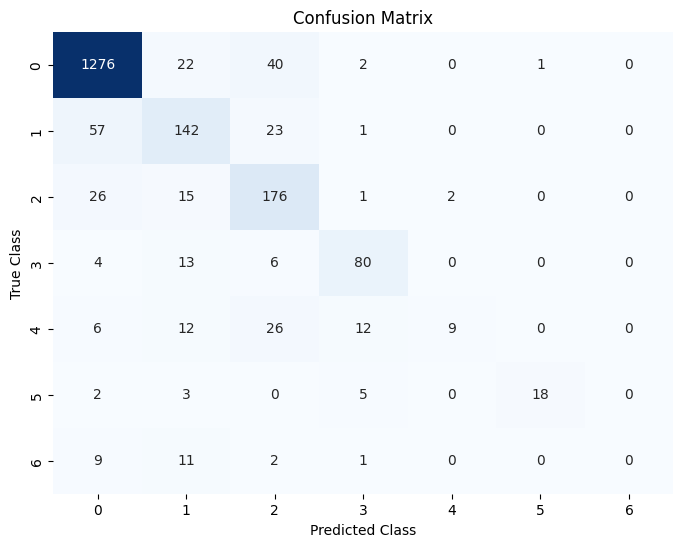

In [105]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [106]:
metrics_names = ['Precision', 'Recall', 'F1 Score', 'Avg Precision', 'Specificity']
metrics_values = [precision, recall, f1, avg_prec, specificity]

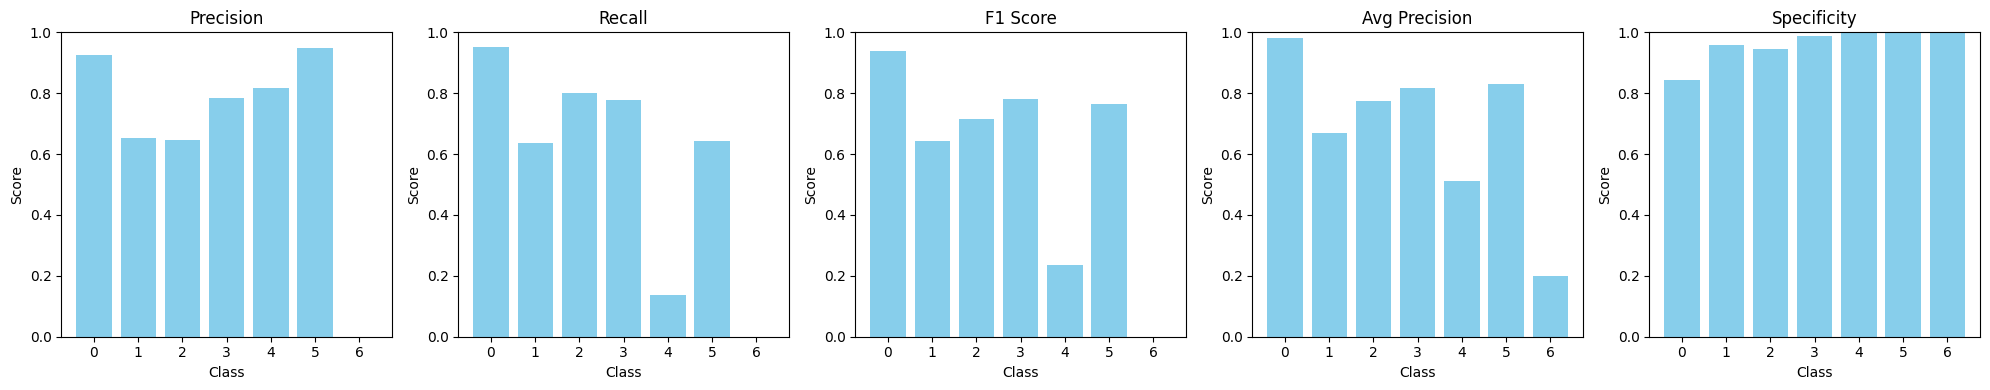

In [107]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, (name, values) in enumerate(zip(metrics_names, metrics_values)):
    axs[i].bar(range(num_classes), values, color='skyblue')
    axs[i].set_xticks(range(num_classes))
    axs[i].set_ylim(0, 1)
    axs[i].set_title(name)
    axs[i].set_xlabel('Class')
    axs[i].set_ylabel('Score')
plt.tight_layout()
plt.show()

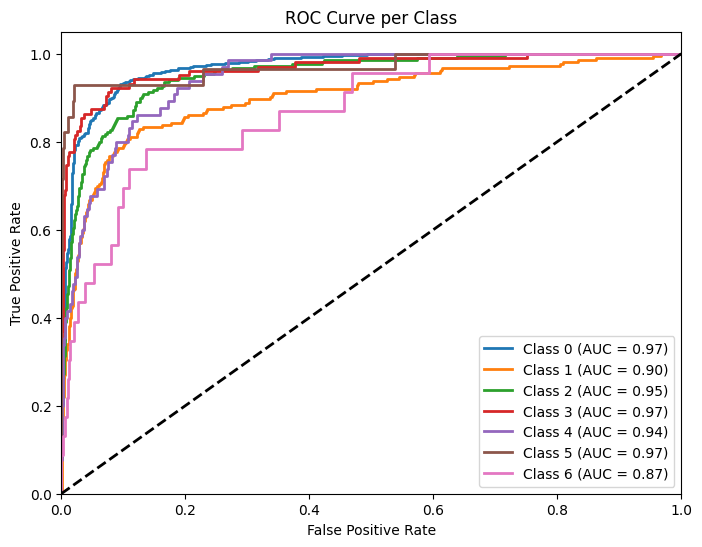

In [112]:
if auc_score is not None:
    plt.figure(figsize=(8, 6))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve per Class')
    plt.legend(loc='lower right')
    plt.show()